# Comparative Study of Deep Learning Architectures for Industrial Image Analysis

## 1. Model Exploration and Benchmarking

This section presents a comparative evaluation of three widely used convolutional neural network (CNN) architectures: **VGG19**, **ResNet50**, and **DenseNet121**. The objective is to analyze their learning behavior, convergence stability, and suitability for industrial predictive maintenance applications.

### VGG19 - Conventional Deep CNN Architecture

VGG19 follows a traditional deep learning design strategy based on stacking convolutional layers with a uniform structure. Its simplicity makes it an important baseline architecture for image classification tasks.

In [ ]:
from tensorflow.keras.applications import VGG19

vgg = VGG19(weights=None)
vgg.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 143,667,240 (548.05 MB)

 Trainable params: 143,667,240 (548.05 MB)

 Non-trainable params: 0 (0.00 B)

The model contains significantly more trainable parameters than a lightweight CNN model such as those commonly used on the MNIST dataset. This higher complexity allows the network to learn richer visual representations, but it also increases computational cost and training time.

### ResNet50 - Residual Learning Architecture

ResNet introduces residual connections (skip connections) that facilitate gradient propagation through deep networks. This design reduces the vanishing gradient problem and accelerates convergence during training.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# resize images and convert them to PyTorch tensors
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
indices = list(range(len(full_trainset)))
labels = full_trainset.targets

# We keep only 10% (train_size=0.1) and discard the rest to speed things up
keep_indices, _ = train_test_split(
    indices, train_size=0.1, stratify=labels, random_state=42
)

# Create the downsized mini-dataset
mini_trainset = Subset(full_trainset, keep_indices)

# Set up the DataLoader (bumping batch_size to 64 for better efficiency!)
trainloader = torch.utils.data.DataLoader(
    mini_trainset, batch_size=64, shuffle=True
)

print(f"Number of training images after reduction: {len(mini_trainset)}")

100%|██████████| 170M/170M [00:16<00:00, 10.1MB/s]


Nombre d'images d'entraînement après réduction : 5000


In [ ]:
vgg = models.vgg19(weights=None)
resnet = models.resnet34(weights=None)

# Adapt the final fully connected layers to output 10 classes (for CIFAR-10)
vgg.classifier[6] = nn.Linear(4096, 10)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

vgg = vgg.to(device)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss()

vgg_optimizer = optim.Adam(vgg.parameters(), lr=0.001)
resnet_optimizer = optim.Adam(resnet.parameters(), lr=0.001)

In [ ]:
def train_model(model, optimizer, epochs=10):
    losses = []

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        losses.append(epoch_loss)

        print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}")

    return losses

In [ ]:
print("Training VGG19...")
vgg_losses = train_model(vgg, vgg_optimizer)

print("\nTraining ResNet34...")
resnet_losses = train_model(resnet, resnet_optimizer)

Training VGG19...
Epoch 1: Loss = 3.1735
Epoch 2: Loss = 2.3033
Epoch 3: Loss = 2.3031
Epoch 4: Loss = 2.3031
Epoch 5: Loss = 2.3030
Epoch 6: Loss = 2.3028
Epoch 7: Loss = 2.3029
Epoch 8: Loss = 2.3029
Epoch 9: Loss = 2.3028
Epoch 10: Loss = 2.3028

Training ResNet34...
Epoch 1: Loss = 1.8764
Epoch 2: Loss = 1.5622
Epoch 3: Loss = 1.4237
Epoch 4: Loss = 1.2628
Epoch 5: Loss = 1.1236
Epoch 6: Loss = 1.0054
Epoch 7: Loss = 0.8399
Epoch 8: Loss = 0.7043
Epoch 9: Loss = 0.5935
Epoch 10: Loss = 0.5078


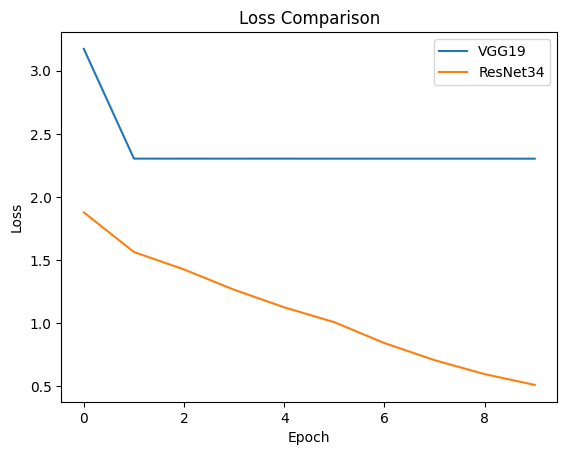

In [ ]:
plt.plot(vgg_losses, label="VGG19")
plt.plot(resnet_losses, label="ResNet34")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison")

plt.legend()
plt.show()

ResNet demonstrates faster and more stable convergence during the early training stages compared to VGG19. Residual connections help the model optimize efficiently even with increased depth.

### DenseNet121 - Dense Feature Reuse Strategy

DenseNet establishes direct connections between layers, enabling extensive feature reuse throughout the network. This architecture improves parameter efficiency while preserving strong representational capacity.

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [ ]:
import  os
dense = models.densenet121(weights=None)


vgg_params = count_parameters(vgg)
dense_params = count_parameters(dense)

print("VGG19 Parameters:", f"{vgg_params:,}")
print("DenseNet121 Parameters:", f"{dense_params:,}")

torch.save(vgg.state_dict(), "vgg19.pth")
torch.save(dense.state_dict(), "densenet121.pth")

vgg_size = os.path.getsize("vgg19.pth") / (1024 * 1024)
dense_size = os.path.getsize("densenet121.pth") / (1024 * 1024)

print(f"\nVGG19 Size: {vgg_size:.2f} MB")
print(f"DenseNet121 Size: {dense_size:.2f} MB")


print("\nVGG19 Depth: 19 layers")
print("DenseNet121 Depth: 121 layers")

VGG19 Parameters: 139,611,210
DenseNet121 Parameters: 7,978,856

VGG19 Size: 532.59 MB
DenseNet121 Size: 31.01 MB

VGG19 Depth: 19 layers
DenseNet121 Depth: 121 layers


Despite containing a larger number of layers, DenseNet121 remains more lightweight than VGG19 due to its efficient parameter-sharing strategy.

## 2. Industrial Maintenance Dataset Preparation

To evaluate these models we construct a synthetic dataset of **spectrogram images** derived from simulated vibration signals. Each signal represents a sensor reading over time from an industrial machine; we label it as either *healthy* (`sain`) or *faulty* (`panne`).

This stage focuses on organizing industrial image data, preprocessing samples, and creating training and validation subsets suitable for deep learning experimentation.

In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
from scipy.signal import spectrogram
import os
import random
import time
import warnings
from pathlib import Path

In [ ]:
AMPLITUDE        = 5            # Amplitude of the basic sinusoidal signal
DURATION         = 6.0          # Signal duration in seconds
FREQ             = 0.8          # Relative frequency for basic signal generation
FREQ_PRINCIPALE  = 50           # Main frequency of the sinusoidal signal in Hz
IMG_SIZE         = (224, 224)   # Size of the generated images for the CNN models
N_IMAGES_CLASSE  = 500          # Number of spectrogram images to generate per class
SAMPLE_RATE      = 1000         # Number of points per second in the simulated signal
SEED             = 42           # Randomization seed to ensure reproducibility
TRAIN_RATIO      = 0.8          # Fraction of images used for training

random.seed(SEED)    # Initialize the Python random number generator
np.random.seed(SEED) # Initialize the NumPy random number generator

In [ ]:
# Output directories
BASE_DIR = Path("dataset")
DIRS = {
    "train_sain"  : BASE_DIR / "train" / "sain",
    "train_panne" : BASE_DIR / "train" / "panne",
    "val_sain"    : BASE_DIR / "val"   / "sain",
    "val_panne"   : BASE_DIR / "val"   / "panne",
    "preview"     : BASE_DIR / "preview",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

In [ ]:
def generer_signal_capteur(seed=42, n_anomalies=3):
    """
    Generates a simulated sensor signal representing both healthy behavior 
    and faulty behavior with anomalies.
    """

    rng = np.random.default_rng(seed) # Initialize the random number generator

    # Create the time vector
    t = np.linspace(
        0,
        DURATION,
        int(SAMPLE_RATE * DURATION),
        endpoint=False
    )

    # Generate a baseline sinusoidal signal
    sig = AMPLITUDE * np.sin(2 * np.pi * FREQ * t)
    sig += 0.8 * np.sin(2 * np.pi * 2 * FREQ * t)

    # Add random Gaussian noise to create the healthy signal
    sig_normal = sig + rng.normal(0, 0.1, size=len(sig))

    # Initialize the faulty signal as a copy of the healthy one
    sig_def = sig_normal.copy()

    labels = np.zeros(len(sig), dtype=np.uint8)
    anomalies = []

    # Insert anomalies into the faulty signal
    for _ in range(n_anomalies):

        length = len(sig)

        # Determine the duration (size) of the anomaly
        taille = rng.integers(
            int(0.05 * length),
            int(0.12 * length)
        )

        # Set the start and end indices of the anomaly
        debut = rng.integers(0, length - taille)
        fin = debut + taille

        # Generate high-amplitude burst noise
        noise = rng.normal(0, 1.2, size=taille)

        # Generate random transient spikes
        spikes = rng.choice([0, 0, 0, 1, -1], size=taille) * rng.uniform(1, 3, size=taille)

        # Inject the noise and spikes into the signal slice
        sig_def[debut:fin] += noise + spikes

        # Mark the anomaly window in the labels array
        labels[debut:fin] = 1
        anomalies.append((debut, fin))

    return t, sig_normal, sig_def, labels, anomalies

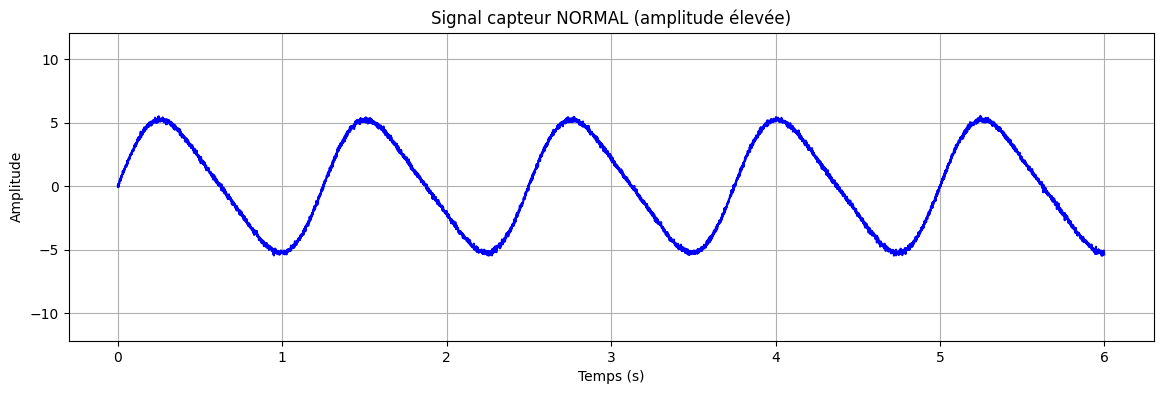

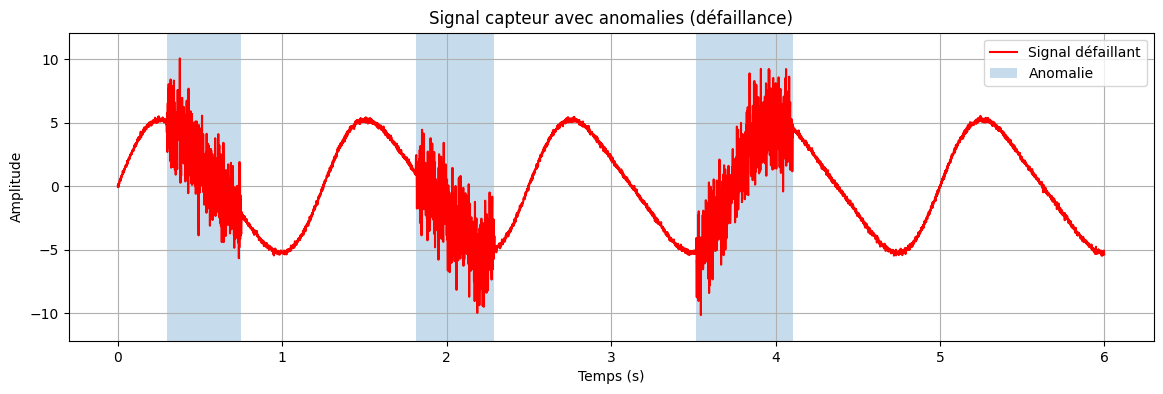

Anomalies détectées :
1: 3518 → 4107
2: 298 → 753
3: 1813 → 2291


In [ ]:
%matplotlib inline

# Generate the simulated sensor signals
t, sig_normal, sig_def, labels, anomalies = generer_signal_capteur()

# Calculate unified y-axis limits with a margin to align both plots perfectly
y_min = min(sig_normal.min(), sig_def.min())
y_max = max(sig_normal.max(), sig_def.max())

margin = 0.1 * (y_max - y_min)
y_min -= margin
y_max += margin


# Plot 1: Normal Signal Visualization
plt.figure(figsize=(14, 4))
plt.plot(t, sig_normal, color="blue")
plt.title("NORMAL Sensor Signal (High Amplitude)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.ylim(y_min, y_max)
plt.grid(True)
plt.show()

# Plot 2: Faulty Signal Visualization
plt.figure(figsize=(14, 4))
plt.plot(t, sig_def, color="red", label="Faulty Signal")

# Highlight anomaly regions with background shading
for i, (d, f) in enumerate(anomalies):
    plt.axvspan(
        t[d],
        t[f-1],
        alpha=0.25,
        label="Anomaly" if i == 0 else None
    )

plt.title("Sensor Signal with Anomalies (Failure Mode)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.ylim(y_min, y_max)
plt.legend()
plt.grid(True)
plt.show()

# Print generated anomaly indices for validation
print("Anomalies détectées :")
for i, (d, f) in enumerate(anomalies):
    print(f"{i+1}: {d} → {f}")

In [ ]:
def signal_vers_spectrogramme(signal, path, sample_rate=1000):
    """
    Converts a time-domain signal into a spectrogram and saves it as an image.
    """

    # Compute the Short-Time Fourier Transform (STFT)
    f, t, Sxx = spectrogram(
        signal,
        fs=sample_rate,
        nperseg=256,
        noverlap=128
    )

    # Convert the spectrogram amplitude to decibels (dB) for enhanced visualization
    Sxx_db = 10 * np.log10(Sxx + 1e-10)

    plt.figure(figsize=(3, 3))

    # Plot the spectrogram matrix
    plt.pcolormesh(
        t,
        f,
        Sxx_db,
        shading='gouraud'
    )
    plt.axis("off")

    # Save the generated figure as a PNG image
    plt.savefig(
        path,
        bbox_inches='tight',
        pad_inches=0,
        dpi=100
    )

    plt.close()

<h3>Why Short-Time Fourier Transform (STFT)</h3>

The standard Fourier Transform is great at telling which frequencies exist in a signal, but it is completely blind to when they occur.

The STFT introduces a clever workaround: instead of analyzing the whole signal at once, it breaks the signal down into small, overlapping time chunks (windows).

- Windowing: It multiplies the signal by a short window function (like a Hann or Gaussian window).

- FFT: It applies the standard Fourier Transform to just that small chunk.

- Sliding: It slides the window a bit further down the time axis (overlapping with the previous chunk) and repeats the process.

By doing this across the entire length of the signal, STFT provides a map of frequencies for each specific time interval.


In [ ]:
def generate_dataset():
    """
    Generates a dataset of spectrogram images from simulated sensor signals.
    Splits the data into training and validation sets for 'healthy' and 'faulty' classes.
    """

    # Calculate the number of training images for each class
    n_train = int(N_IMAGES_CLASSE * TRAIN_RATIO)

    # Loop through both target classes: 'sain'(healthy) and 'panne'(faulty)
    for nom_classe in ["sain", "panne"]:

        print(f"  Génération classe : {nom_classe.upper()}")

        dossier_train = DIRS[f"train_{nom_classe}"]
        dossier_val = DIRS[f"val_{nom_classe}"]

        # Generate N_IMAGES_CLASSE items for the current class
        for i in range(N_IMAGES_CLASSE):

            # Define a unique seed for each signal to ensure diversity and reproducibility
            seed_i = SEED + i + (10000 if nom_classe == "panne" else 0)

            # Call the sensor signal generation function to get healthy and faulty waveforms
            t_sig, sig_normal, sig_def, _, _ = generer_signal_capteur(seed=seed_i)

            # Select the appropriate signal variant based on the current class iteration
            if nom_classe == "sain":
                sig_to_process = sig_normal
            else:
                sig_to_process = sig_def

            # Assign the destination path based on the training/validation split ratio
            if i < n_train:
                chemin = dossier_train / f"{nom_classe}_{i:04d}.png"
                split = "train"
            else:
                chemin = dossier_val / f"{nom_classe}_{i:04d}.png"
                split = "val"

            # Convert the selected 1D time signal to a 2D spectrogram and save as a PNG image
            signal_vers_spectrogramme(sig_to_process, chemin, sample_rate=SAMPLE_RATE)

            if (i + 1) % 50 == 0:
                print(f"  [{split}] {i+1}/{N_IMAGES_CLASSE} images générées...")

    print("\nDataset complet généré !")

    # Display final directory statistics after generation completes
    display_statistics()

In [ ]:
def afficher_statistiques():
    """
    Counts and prints the number of images per class across data splits.
    """

    print("\nStatistiques du dataset :")
    print(f"  {'Split':<8} {'Classe':<10} {'Images':>8}")
    print(f"  {'-'*30}")

    for cle, dossier in DIRS.items():
        if cle == "preview":
            continue
        n = len(list(dossier.glob("*.png")))
        split, classe = cle.split("_", 1)
        print(f"  {split:<8} {classe:<10} {n:>8}")
        
    total = sum(
        len(list(d.glob("*.png")))
        for k, d in DIRS.items() if k != "preview"
    )
    print(f"  {'-'*30}")
    print(f"  {'TOTAL':<18} {total:>8}")

In [ ]:
def visualiser_exemples():
    """
    Generates and plots time-domain and STFT spectrogram comparisons 
    between healthy and faulty sensor signals.
    """

    # Signal generation
    t, sig_sain, _, _, _ = generer_signal_capteur(seed=42)
    _, _, sig_panne, _, _ = generer_signal_capteur(seed=141)

    # STFT Computation (Short-Time Fourier Transform)
    f_sain, t_sain, Z_sain = scipy_signal.stft(sig_sain, fs=SAMPLE_RATE)
    f_panne, t_panne, Z_panne = scipy_signal.stft(sig_panne, fs=SAMPLE_RATE)

    # Convert magnitude to decibels (dB)
    spec_sain = 20 * np.log10(np.abs(Z_sain) + 1e-10)
    spec_panne = 20 * np.log10(np.abs(Z_panne) + 1e-10)

    # --- HEALTHY SIGNAL PLOTS ---
    plt.figure(figsize=(10, 6))

    plt.subplot(2, 2, 1)
    plt.plot(t, sig_sain, color="green")
    plt.title("Signal sain")
    plt.xlabel("Temps (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.imshow(
        spec_sain,
        aspect="auto",
        origin="lower",
        extent=[
            t_sain.min(),
            t_sain.max(),
            f_sain.min(),
            f_sain.max()
        ],
        cmap="viridis"
    )
    plt.title("Spectrogramme STFT - Signal sain")
    plt.xlabel("Temps (s)")
    plt.ylabel("Fréquence (Hz)")
    plt.colorbar(label="Magnitude (dB)")

    plt.tight_layout()
    plt.show()

    # --- FAULTY SIGNAL PLOTS ---
    plt.figure(figsize=(10, 6))

    plt.subplot(2, 2, 3)
    plt.plot(t, sig_panne, color="red")
    plt.title("Signal en panne")
    plt.xlabel("Temps (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.imshow(
        spec_panne,
        aspect="auto",
        origin="lower",
        extent=[
            t_panne.min(),
            t_panne.max(),
            f_panne.min(),
            f_panne.max()
        ],
        cmap="Reds"
    )
    plt.title("Spectrogramme STFT - Signal en panne")
    plt.xlabel("Temps (s)")
    plt.ylabel("Fréquence (Hz)")
    plt.colorbar(label="Magnitude (dB)")

    plt.tight_layout()
    plt.show()

  Génération classe : SAIN
  [train] 50/500 images générées...
  [train] 100/500 images générées...
  [train] 150/500 images générées...
  [train] 200/500 images générées...
  [train] 250/500 images générées...
  [train] 300/500 images générées...
  [train] 350/500 images générées...
  [train] 400/500 images générées...
  [val] 450/500 images générées...
  [val] 500/500 images générées...
  Génération classe : PANNE
  [train] 50/500 images générées...
  [train] 100/500 images générées...
  [train] 150/500 images générées...
  [train] 200/500 images générées...
  [train] 250/500 images générées...
  [train] 300/500 images générées...
  [train] 350/500 images générées...
  [train] 400/500 images générées...
  [val] 450/500 images générées...
  [val] 500/500 images générées...

Dataset complet généré !

Statistiques du dataset :
  Split    Classe       Images
  ------------------------------
  train    sain            400
  train    panne           400
  val      sain            100
  val

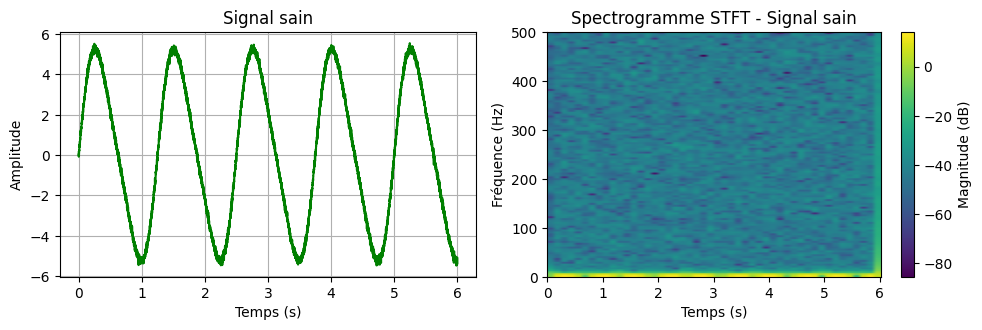

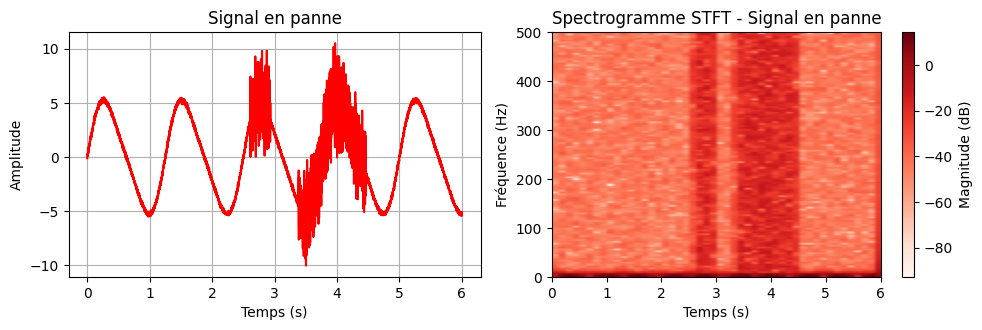

In [ ]:
generer_dataset()
visualiser_exemples()

In [ ]:
def creer_generateurs():
    """
    Light data augmentation on the training set (rotation, flip).
    Validation without augmentation → reliable evaluation.
    """
    gen_train = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=5,        # The model shouldn't memorize an exact orientation. It needs to learn patterns.
        width_shift_range=0.05,  # The image can move horizontally by 5%, simulating a slight temporal shift.
        height_shift_range=0.05, # This simulates small frequency variations.
        horizontal_flip=True,
        fill_mode='nearest',     # when rotating or moving an image, this fills the empty space
    )
    gen_val = ImageDataGenerator(rescale=1.0 / 255)

    train_ds = gen_train.flow_from_directory(
        f"{DATASET_DIR}/train",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASSES,
        seed=SEED,
        shuffle=True,
    )
    val_ds = gen_val.flow_from_directory(
        f"{DATASET_DIR}/val",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASSES,
        seed=SEED,
        shuffle=False,
    )

    print(f"\n    Classes détectées : {train_ds.class_indices}")
    print(f"   Train : {train_ds.samples} images | Val : {val_ds.samples} images")
    return train_ds, val_ds

## 3. Models Training

We train the VGG-19, ResNet-50 and DenseNet-121 models on the generated spectrogram dataset to evaluate their performance. This step involves feeding the augmented data through each network, computing errors via cross-entropy loss, and updating weights using the Adam optimizer.

This stage focuses on executing the training loop, tracking accuracy and loss, and monitoring validation metrics to prevent overfitting.

In [ ]:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG19, ResNet50, DenseNet121
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)

print(f"TensorFlow version : {tf.__version__}")

TensorFlow version : 2.20.0


In [ ]:
DATASET_DIR  = "dataset"         # Root directory containing the training and validation images
OUTPUT_DIR   = "resultats"       # Save outputs
BATCH_SIZE   = 16                # Number of images processed simultaneously before updating weights
EPOCHS       = 20                # Epochs
LR_INIT      = 1e-4              # Learning rate
FINE_TUNE    = True              # Flag to enable unfreezing base network layers for fine-tuning
CLASSES      = ["sain", "panne"] # Target labels for the classification task

# Create the main results output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Create a subdirectory specifically for storing model checkpoints
os.makedirs(f"{OUTPUT_DIR}/checkpoints", exist_ok=True)

In [ ]:
# CALLBACKS
def creer_callbacks(nom: str):
    """
    Creates and returns the Keras callbacks used during model training.
    """

    return [
        # Stops training early if validation accuracy stops improving
        EarlyStopping(
            monitor='val_accuracy',      # Directly monitors classification performance
            patience=5,
            restore_best_weights=True,  # Reverts model weights to those of the best epoch upon stopping
            mode='max',                 # Training stops when the monitored quantity ceases to increase
            verbose=1,
        ),

        # Dynamically reduces the learning rate when the validation loss plateaus
        ReduceLROnPlateau(
            monitor='val_loss',         # Monitors validation loss trends
            factor=0.5,                 # Multiplies the learning rate by 0.5 (cuts it in half)
            patience=3,                 # Number of epochs to wait before dropping the learning rate
            min_lr=1e-7,                # Lower bound limit for the learning rate reduction
            mode='min',                 # Reduction triggers when the monitored quantity ceases to decrease
            verbose=1,
        ),

        # Periodically saves the absolute best version of the model during training
        ModelCheckpoint(
            filepath=f"{OUTPUT_DIR}/checkpoints/{nom}_best.keras",
            monitor='val_accuracy',     # Keeps track of the highest validation accuracy achieved
            save_best_only=True,        # Only overwrites the file if validation performance improves
            mode='max',                 # Overwrites when the monitored metric reaches a new maximum
            verbose=1,
        ),
    ]

In [ ]:
def construire_modele(nom: str, fine_tune: bool = FINE_TUNE):
    """
    Builds, configures, and compiles VGG19, ResNet50, or DenseNet121 architectures
    """

    inputs = keras.Input(shape=(*IMG_SIZE, 3))

    kwargs = dict(weights='imagenet', include_top=False, input_tensor=inputs)

    if nom == "VGG19":
        base = VGG19(**kwargs)
        n_ft = 4
    elif nom == "ResNet50":
        base = ResNet50(**kwargs)
        n_ft = 20
    elif nom == "DenseNet121":
        base = DenseNet121(**kwargs)
        n_ft = 20
    else:
        raise ValueError("Modèle inconnu")

    # Freeze base
    base.trainable = False

    # Custom classification head
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name=nom)

    model.compile(
        optimizer=keras.optimizers.Adam(LR_INIT),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ],
    )

    # Fine-tuning
    if fine_tune:
        base.trainable = True

        # Keep early feature extraction layers frozen
        for layer in base.layers[:-n_ft]:
            layer.trainable = False

        # Unfreeze only the final 'n_ft' blocks for targeted feature alignment
        for layer in base.layers[-n_ft:]:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

        model.compile(
            optimizer=keras.optimizers.Adam(LR_INIT / 10),
            loss='binary_crossentropy',
            metrics=[
                'accuracy',
                keras.metrics.AUC(name='auc'),
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
            ],
        )

    return model

In [ ]:
def entrainer_modele(nom, train_ds, val_ds):
    """
    Trains the specified model architecture and returns the resulting objects and metrics.
    Visualization steps are omitted here for clean separation of concerns.
    """

    print("MODELE:", nom)

    # Initialize and compile the neural network architecture
    model = construire_modele(nom)

    # Track execution runtime for processing performance comparison
    start = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=creer_callbacks(nom),
        verbose=1
    )

    duration = time.time() - start

    # Final evaluation against the validation dataset partition
    results = model.evaluate(val_ds, verbose=0)
    metrics = dict(zip(model.metrics_names, results))

    # Generate inference predictions for downstream validation metrics
    val_ds.reset()
    y_proba = model.predict(val_ds).flatten()
    y_pred = (y_proba >= 0.5).astype(int) # Apply standard binary threshold
    y_true = val_ds.classes

    return {
        "nom": nom,
        "model": model,
        "history": history.history,
        "metrics": metrics,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "time": duration
    }

In [ ]:
def tracer_courbes(results):
    """
    Plots the Training/Validation Loss and Accuracy metrics for all trained models
    side-by-side using clean subplots.
    """

    n = len(results)

    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n))

    # Handle indexing edge case if only a single model exists in the results list
    if n == 1:
        axes = [axes]

    for i, r in enumerate(results):

        h = r["history"]
        nom = r["nom"]

        epochs_range = range(1, len(h['loss']) + 1)

        # LOSS
        axes[i][0].plot(epochs_range, h['loss'], label='Train Loss')
        axes[i][0].plot(epochs_range, h['val_loss'], label='Val Loss')

        axes[i][0].set_title(f'{nom} - Loss')
        axes[i][0].set_xlabel('Epochs')
        axes[i][0].set_ylabel('Loss')
        axes[i][0].legend()
        axes[i][0].grid(True)

        # ACCURACY
        axes[i][1].plot(epochs_range, h['accuracy'], label='Train Accuracy')
        axes[i][1].plot(epochs_range, h['val_accuracy'], label='Val Accuracy')

        axes[i][1].set_title(f'{nom} - Accuracy')
        axes[i][1].set_xlabel('Epochs')
        axes[i][1].set_ylabel('Accuracy')
        axes[i][1].legend()
        axes[i][1].grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
import gc

print("START TRAINING")

# Initialize the data generators for the training and validation splits
train_ds, val_ds = creer_generateurs()

results = []

# Iterate through and train each specified convolutional neural network architecture
for model_name in ["VGG19", "ResNet50", "DenseNet121"]:

    # Train the model and append its performance dictionary to the results list
    resultat = entrainer_modele(model_name, train_ds, val_ds)
    results.append(resultat)
    
    # Reset the Keras global state and clear the GPU/CPU memory graph session
    keras.backend.clear_session()
    
    # Force the Python garbage collector to release unused RAM chunks immediately
    gc.collect()

print("\nDONE TRAINING")

START TRAINING
Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.

    Classes détectées : {'sain': 0, 'panne': 1}
   Train : 800 images | Val : 200 images
MODELE: VGG19
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.7792 - auc: 0.8832 - loss: 0.5030 - precision: 0.7350 - recall: 0.9245
Epoch 1: val_accuracy improved from None to 0.50000, saving model to resultats/checkpoints/VGG19_best.keras

Epoch 1: finished saving model to resultats/checkpoints/VGG19_best.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 400ms/step - accuracy: 0.9038 - auc: 0.9813 - loss: 0.3436 - precision: 0.8597 - recall: 0.9650 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 0.5820 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.9926 - auc: 0.9997 - loss: 0.1564 - precision: 0.9945 - recall: 0.9910
Epoch 2: val_accuracy improved from 0.50000 to 1.00000, saving model to resultats/c

## 4. Experimental Results and Performance Comparison

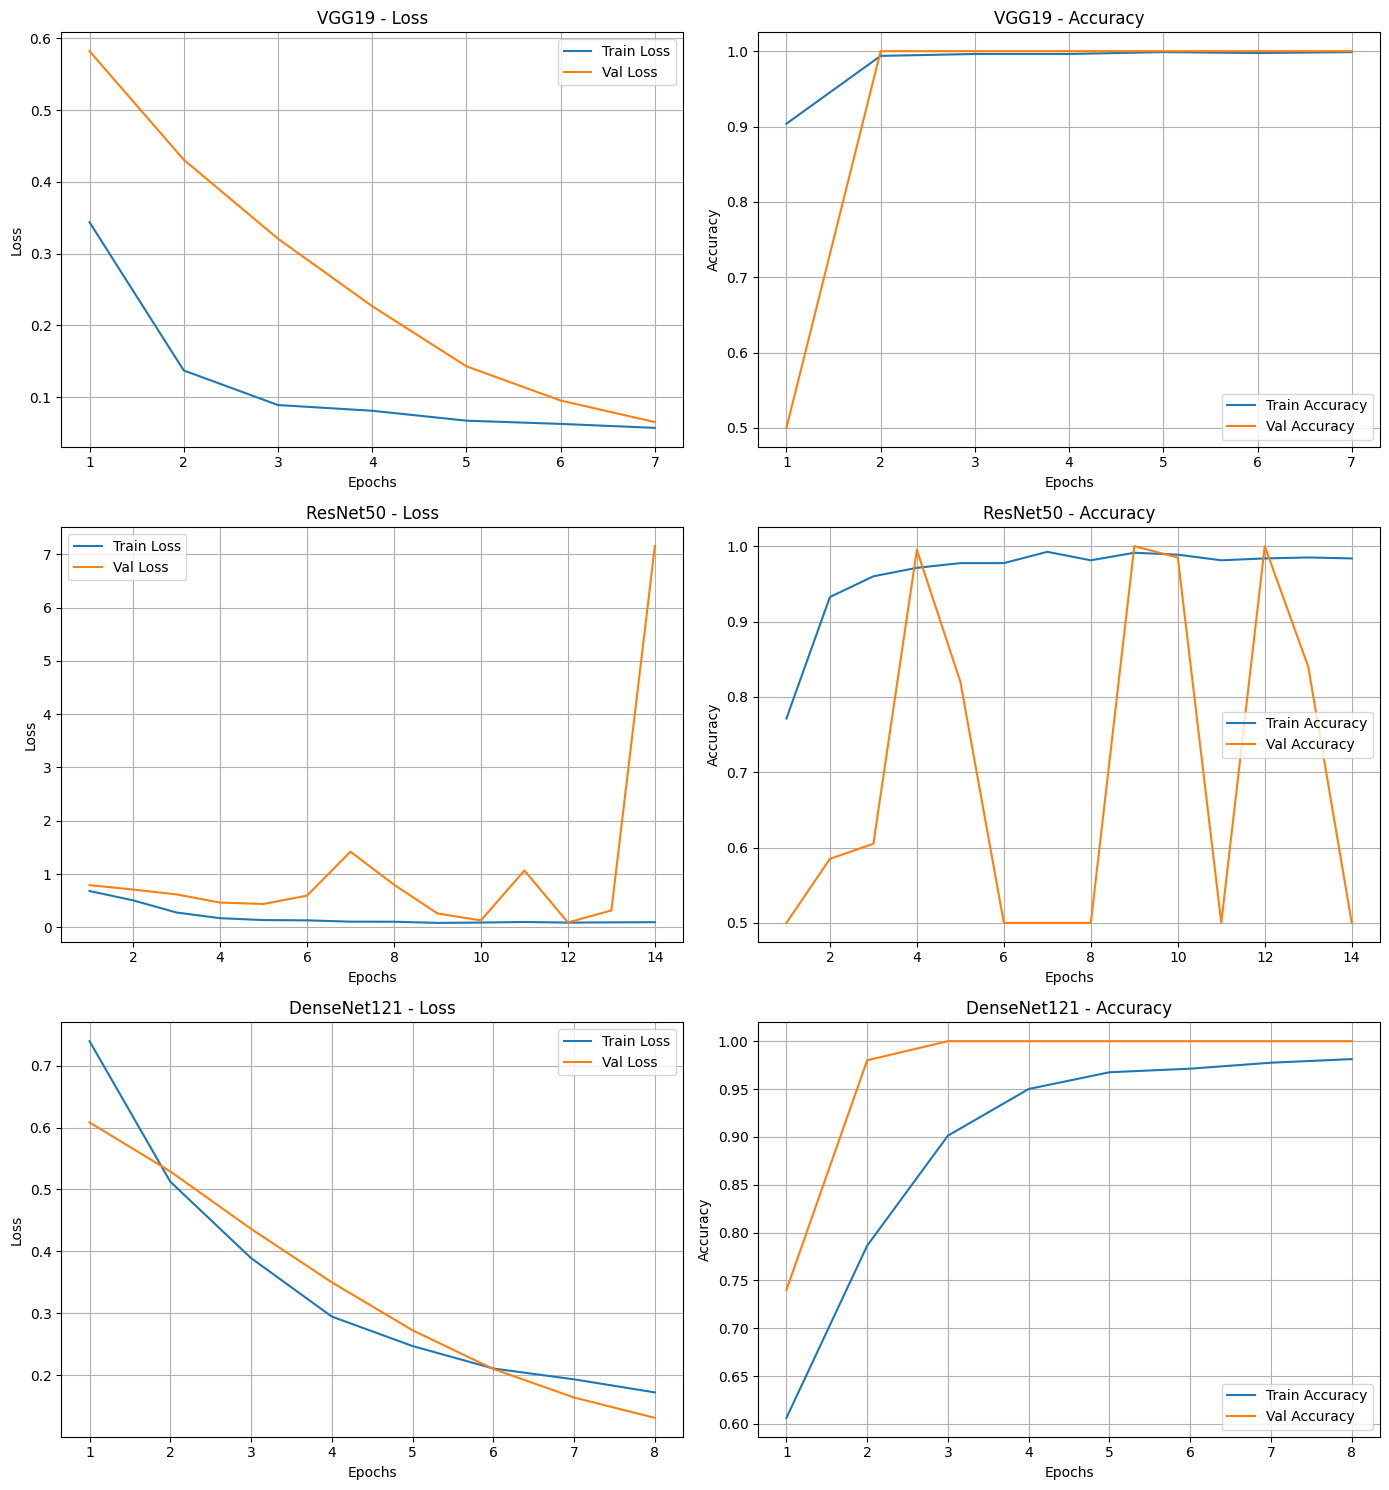

In [ ]:
tracer_courbes(results)

The training and validation curves provide important insights into the behavior and stability of the three CNN architectures during training.

> Note: The dataset used in this experiment is synthetic and relatively simple, which explains the very high validation accuracies achieved by the models. In a real industrial environment with noisy and heterogeneous sensor data, model performance would typically be lower and generalization would be more challenging.

#### VGG19
VGG19 demonstrates stable and consistent learning behavior. Both training and validation loss decrease progressively across epochs, while accuracy rapidly converges toward 100%. The close alignment between training and validation metrics suggests good generalization and limited overfitting on this dataset.

#### ResNet50
ResNet50 achieves high training accuracy very quickly; however, the validation curves are highly unstable. Large fluctuations in validation loss and accuracy indicate inconsistent generalization behavior. This instability may be caused by the limited dataset size, sensitivity to hyperparameters, or overfitting during training.

#### DenseNet121
DenseNet121 exhibits the most balanced and smooth convergence among the tested architectures. Training and validation losses decrease steadily, while validation accuracy reaches near-perfect performance early in training and remains stable. The architecture benefits from efficient feature reuse, leading to strong learning stability and robust performance.

#### Overall Comparison
Among the evaluated models, DenseNet121 provides the best trade-off between stability, convergence quality, and predictive performance. VGG19 also delivers strong results but with higher computational complexity. In contrast, ResNet50 shows unstable validation behavior despite excellent training accuracy, making it less reliable for this specific industrial dataset.

# Application to Predictive Maintenance Systems

The experiments conducted in this project highlight the potential of modern deep learning architectures for industrial predictive maintenance applications. Beyond their strong classification performance, these models demonstrate the ability to learn meaningful feature representations from complex industrial data.

Among the evaluated architectures, DenseNet121 and VGG19 showed the most stable learning behavior and achieved the best overall results on the synthetic dataset. DenseNet121, in particular, offers an attractive balance between performance and parameter efficiency, making it a strong candidate for deployment in resource-constrained environments.

These findings provide a foundation for more advanced predictive maintenance pipelines. In real-world scenarios, industrial systems generate large volumes of sensor data that can be transformed into informative visual or temporal representations. The feature extraction capabilities of deep neural networks can then be leveraged to support tasks such as fault detection, anomaly identification, health monitoring, and Remaining Useful Life (RUL) estimation.

A natural extension of this work is the integration of CNN-based feature extractors with sequential models such as LSTMs or Transformers. Such hybrid architectures can combine spatial feature learning with temporal pattern modeling, enabling more accurate predictions of machine degradation and future system behavior.

While the results obtained in this study are encouraging, it is important to note that the experiments were conducted on a synthetic dataset. Future work should focus on evaluating these architectures on real industrial data, where noise, variability, and operational complexity present additional challenges for robust model generalization.


# Authors

- Manal ES-SOBHY
- Nizar Baloubali